# <span style = 'color:darkorange; font-family:Wild Wolf'>Mini-Batch Gradient Descent<span>

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import random

In [2]:
df = pd.read_csv('bmi_dataset.csv')
df.head()

,wt_kg,ht_cm,bmi
0,77.0,181.7,23.32
1,113.6,178.8,35.53
2,107.1,168.8,37.59
3,86.5,187.8,24.53
4,63.2,171.4,21.51


In [13]:
# features and target
x = df.iloc[:, 0:2]
y = df.iloc[:, -1]

# normalize data
x = (x - x.mean()) / x.std()
y = (y - y.mean()) / y.std()

In [14]:
# sklearn for comparison
from sklearn.metrics import r2_score
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# data split
x_train, x_test, y_train, y_test = train_test_split(x,y, test_size=0.2, random_state=42)
x_train = x_train.values
y_train = y_train.values

lr = LinearRegression()
# start = time.time()
lr.fit(x_train, y_train)
y_pred_sk = lr.predict(x_test)

r2_sk = r2_score(y_test, y_pred_sk)
print('R2_score (sklearn):',r2_sk)
print('Intercept:', lr.intercept_)
print('Coefficients:', lr.coef_)

R2_score (sklearn): 0.9749468965203073
Intercept: -0.002048682415170152
Coefficients: [ 0.84775767 -0.4754333 ]


/Users/lucifer/Library/Python/3.9/lib/python/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


In [22]:
# custom class
class mini_batch:
    def __init__(self,learning_rate, epochs, batch_size):
        self.batch_size = batch_size        # no. of elements in a batch
        self.n = learning_rate
        self.epochs = epochs
        self.loss_list = []
        self.coef_ = None
        self.intercept_ = None
    
    def fit(self, x_train, y_train):
        self.coef_ = np.ones(x_train.shape[1])
        self.intercept_ = 0
        
        for i in range(self.epochs):
            no_batches = int(x_train.shape[0] / self.batch_size)

            for j in range(no_batches):
                idx = random.sample(range(x_train.shape[0]), self.batch_size)

                y_pred = self.intercept_ + np.dot(x_train[idx], self.coef_)

                # update intercept
                grad_intercept = (-2/self.batch_size) * np.sum(y_train[idx] - y_pred)
                self.intercept_ -= (self.n * grad_intercept)

                # update coef
                grad_coef = (-2/self.batch_size) * np.dot((y_train[idx] - y_pred), x_train[idx])
                self.coef_ -= (self.n * grad_coef)

            prediction = self.intercept_ + np.dot(x_train, self.coef_)
            loss = np.mean((y_train - prediction)**2)
            self.loss_list.append(loss)
            print(f'step {i} | loss = {loss}')
        print('✅ final parameters...')
        print('Intercept:', self.intercept_)
        print('Coefficients:', self.coef_)
    
    def predict(self, x_test):
        return self.intercept_ + np.dot(x_test, self.coef_)

In [27]:
# model training
gd = mini_batch(0.1, 100, 100) # batch size of 100 elements, hence 10 batches
start = time.time()
gd.fit(x_train, y_train)
print('Model train time:', time.time() - start)

step 0 | loss = 0.09071823160231395
step 1 | loss = 0.024788611476941124
step 2 | loss = 0.023178144041750733
step 3 | loss = 0.0231176116104968
step 4 | loss = 0.023104509081819456
step 5 | loss = 0.0231559469256465
step 6 | loss = 0.023154318668987955
step 7 | loss = 0.023146936143360494
step 8 | loss = 0.023109196844833462
step 9 | loss = 0.02308312553241436
step 10 | loss = 0.023148498544661403
step 11 | loss = 0.023149953064180582
step 12 | loss = 0.023112095822891945
step 13 | loss = 0.023078099400440585
step 14 | loss = 0.023197478581313175
step 15 | loss = 0.023120943075070538
step 16 | loss = 0.023127959976901237
step 17 | loss = 0.0231854020172062
step 18 | loss = 0.023330783728979405
step 19 | loss = 0.023143173420156437
step 20 | loss = 0.023172499958334595
step 21 | loss = 0.023105793005818106
step 22 | loss = 0.023166668268060384
step 23 | loss = 0.023098091197975405
step 24 | loss = 0.02314753028007967
step 25 | loss = 0.023346032963640635
step 26 | loss = 0.023184043548

In [28]:
y_pred_cc = gd.predict(x_test)
r2_cc = r2_score(y_test, y_pred_cc)
r2_cc

0.9750556424643271

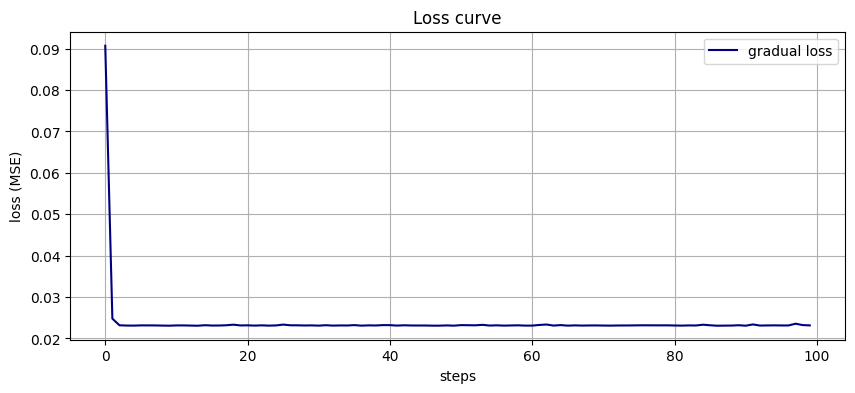

In [30]:
# loss curve
plt.figure(figsize=(10,4))
plt.plot(range(gd.epochs), gd.loss_list, color = 'navy', label = 'gradual loss')
plt.xlabel('steps')
plt.ylabel('loss (MSE)')
plt.title('Loss curve')
plt.legend()
plt.grid(True)
plt.show()

In [32]:
# user input

# features mean
weight_mean = df.iloc[:,0].mean()
height_mean = df.iloc[:, 1].mean()

# features standard deviation
weight_std = df.iloc[:,0].std()
height_std = df.iloc[:, 1].std()

# target mean and std
y_mean = df.iloc[:, -1].mean()
y_std = df.iloc[:, -1].std()

# user input
wt = float(input('Weight(kg): '))
ht = float(input('Height(cm): '))

# normalize user input
wt_norm = (wt - weight_mean) / weight_std
ht_norm = (ht - height_mean) / height_std

# normalized prediction
pred_norm = gd.predict(np.array([[wt_norm,ht_norm]]))

# de-normalize prediciton
pred_final = (pred_norm * y_std) + y_mean
print(f'Predicted BMI: {pred_final[0]:.2f}')

Predicted BMI: 24.61
